In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Підвищимо розмір графіків за замовчуванням
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6

In [4]:
# Матриця суміжності графа
# Тут нуль означає відсутність ребра між вузлами

Adj = np.asarray([[0, 7, 9, 0, 0, 14],
                  [7, 0, 10, 17, 0, 0],
                  [9, 10, 0, 11, 0, 2],
                  [0, 17, 11, 0, 6, 0],
                  [0, 0, 0, 6, 0, 9],
                  [14, 0, 2, 0, 9, 0]])


Побудований орієнтований граф:


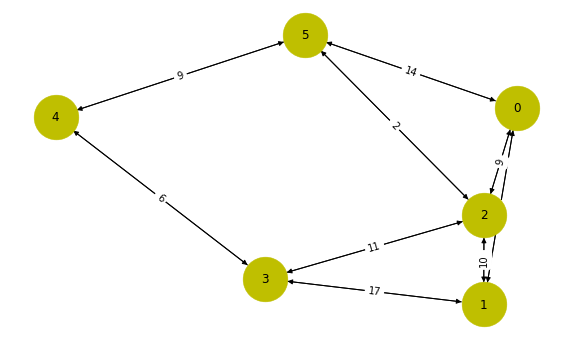

In [15]:
# Зображення орієнтованого графа
G = nx.DiGraph()

N = Adj.shape[0]
for i in range(N):
  G.add_node(i)
  
for i in range(N):
  for j in range(N):
    if Adj[i,j] > 0:
      G.add_edges_from([(i, j)], weight=Adj[i, j])

print("Побудований орієнтований граф:")

pos=nx.spring_layout(G) 
edge_labels=dict([((u, v,), d['weight'])
                 for u, v, d in G.edges(data=True)]) 

nx.draw_networkx(G, pos, node_size=2000, node_color='y') 
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()

In [6]:
# Ініціалізація вхідних параметрів для пошуку найкоротшого шляху

distance = np.zeros(N) 
visited = np.ones(N)

#origin = int(input("Початковий вузол: "))
#goal = int(input("Цільовий вузол: "))

origin = 3
goal = 4

In [13]:
%%time

# Алгоритм Дейкстри
visited[origin] = 0

pred = np.zeros(N)
pred[origin] = origin

for j in range(N):
  if Adj[origin,j] == 0 and origin != j: 
    distance[j] = 10e10
    pred[j] = -1
  else:
    distance[j] = Adj[origin,j]
    pred[j] = origin

while np.sum(visited) > 0:
  temp = np.copy(distance) 
  temp[visited == 0] = 10e10
  vmin = np.argmin(temp)
  visited[vmin] = 0
  for j in range(N):
    if Adj[vmin,j] > 0 and distance[j] > distance[vmin] + Adj[vmin, j]: 
      distance[j] = distance[vmin] + Adj[vmin, j]
      pred[j] = vmin

# Найкоротший шлях від початкового вузла до всіх інших
pred = pred.astype(int)

Wall time: 0 ns


In [8]:
visited

array([0., 0., 0., 0., 0., 0.])

In [9]:
distance

array([20., 17., 11.,  0.,  6., 13.])

In [10]:
pred

array([2, 3, 3, 3, 3, 2])

Найкоротший шлях від 3 до 4:
4 <-- 3

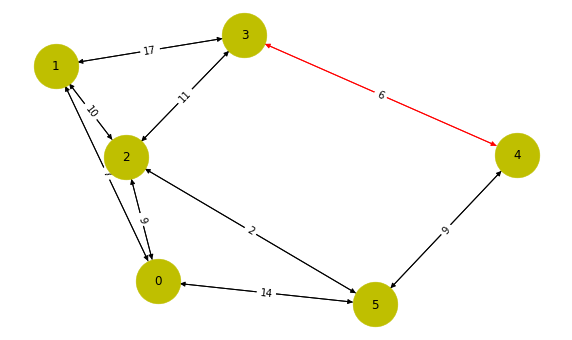

In [11]:
# Зображення найкоротшого шляху на графі

previous = pred[goal]
path = [(previous, goal),(goal, previous)]
print("Найкоротший шлях від " + str(origin) + " до " + str(goal) + 
      ":\n" + str(goal) + " <-- " + str(previous), end="")

while previous != origin:
  path.append((previous, pred[previous]))
  path.append((pred[previous], previous))
  previous = pred[previous]
  print(" <-- "+str(previous), end="")

edge_colors = ['black' if not edge in path else 'red' for edge in G.edges()]

pos=nx.spring_layout(G)
edge_labels=dict([((u, v,),d['weight'])
                 for u, v, d in G.edges(data=True)])

nx.draw_networkx(G, pos, node_size=2000, node_color='y', edge_color=edge_colors)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()